# Olist E-Commerce: Exploratory Data Analysis

Analysis of Brazilian e-commerce orders to explore sales trends, delivery performance and customer satisfaction.

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Tools:** pandas, seaborn, matplotlib

## 1. Data loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')

In [2]:
# translate the names of the categories to english
translation = pd.read_csv('../data/product_category_name_translation.csv')
products = products.merge(translation, on='product_category_name', how='left')

# now we have a new column - product_category_name_english

In [3]:
orders.info()
items.info()
products.info()
customers.info()
reviews.info()
payments.info()
sellers.info()
geolocation.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 no

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [7]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [9]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [10]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [11]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [12]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [13]:
items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [14]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [15]:
reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [16]:
payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Observations:**
1. 8 tables, ~100k orders from 2016 to 2018.
2. Key join columns: `order_id`, `product_id`, `customer_id`, `seller_id`
3. Date columns stored as strings, so they need conversion
4. Missing values present in products, reviews and delivery dates (handled in next section)
5. 8 unique order statuses in `order_status` (should check them later)
6. Minimum product weight is 0. Likely digital goods or data entry error, worth checking

## 2. Missing values

### orders

The orders table contains 99441 entries with missing values in:
1. `order_approved_at` – ~160 nulls (unapproved orders)
2. `order_delivered_carrier_date` – ~1,800 nulls
3. `order_delivered_customer_date` – ~2,900 nulls

These likely represent cancelled or undelivered orders. Keeping them as-is – useful for delivery performance analysis. For delivery time calculations, will filter by `order_status == 'delivered'`.

### products
There are two key issues in this table. First – 2 products have no weight, length, height or width. This could be digital goods or missing data.

In [17]:
products.loc[products['product_weight_g'].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN,baby
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The first product belongs to the baby category. It has no measurements, but has photos, name and description. The second one is fully NaN except for `product_id`. Both were ordered (confirmed by merging with the items table), so leaving them as-is.

Second issue: ~610 nulls in `product_category_name`. Filled them with `'unknown'` value.

In [18]:
products.product_category_name_english = products['product_category_name_english'].fillna('unknown')

### reviews
There are missing values in review title (~87k) and review message (~58k). That is expected, because not everyone leaves comments. The `review_score` column is fully populated, which is what matters for analysis.

## 3. Preparing data

The first step of data preparation – translating category names from Portuguese to English – was done earlier. The next step is converting date columns from strings to datetime. Three tables have this issue: orders, items, and reviews.

In [19]:
# conversion for orders table

orders_dates = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in orders_dates:
    orders[col] = pd.to_datetime(orders[col])

# conversion for items table

items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])

# conversion for reviews table

reviews_dates = ['review_creation_date', 'review_answer_timestamp']

for col in reviews_dates:
    reviews[col] = pd.to_datetime(reviews[col])

reviews['review_answer_timestamp'].head(3)


0   2018-01-18 21:46:59
1   2018-03-11 03:05:13
2   2018-02-18 14:36:24
Name: review_answer_timestamp, dtype: datetime64[us]

The last step in this section is creating two helper columns for later analysis: delivery time in days and month of purchase for seasonality analysis.

In [20]:
# delivery time in days (NaT if order wasn't delivered)

orders = orders.assign(order_delivery_time=lambda orders: (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days)

# month of purchase

orders = orders.assign(month_of_purchase=orders['order_purchase_timestamp'].dt.month)

orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_delivery_time,month_of_purchase
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,8


## 4. Distributions

In [35]:
items_products = pd.merge(items, products, on='product_id')
items_products['product_category_name_english'].value_counts()

product_category_name_english
bed_bath_table               11115
health_beauty                 9670
sports_leisure                8641
furniture_decor               8334
computers_accessories         7827
                             ...  
arts_and_craftmanship           24
cds_dvds_musicals               14
la_cuisine                      14
fashion_childrens_clothes        8
security_and_services            2
Name: count, Length: 72, dtype: int64

The most popular category is bed_bath_table (household products for bedroom, bathroom and dining). Since Olist is a marketplace platform connecting various sellers, it's expected that no single category dominates by a wide margin. The top 5 categories are everyday products, while the bottom 5 are niche categories with very few orders.

In [22]:
products['product_category_name_english'].value_counts()

product_category_name_english
bed_bath_table               3029
sports_leisure               2867
furniture_decor              2657
health_beauty                2444
housewares                   2335
                             ... 
tablets_printing_image          9
fashion_childrens_clothes       5
home_comfort_2                  5
security_and_services           2
cds_dvds_musicals               1
Name: count, Length: 72, dtype: int64

One factor behind category popularity is simply the number of products available in each category.

In [23]:
orders['month_of_purchase'].value_counts()

month_of_purchase
8     10843
5     10573
7     10318
3      9893
6      9412
4      9343
2      8508
1      8069
11     7544
12     5674
10     4959
9      4305
Name: count, dtype: int64

Monthly distribution shows higher order counts in months 3-8 and lower in 9-12, but this may reflect incomplete years in the dataset (2016-2018) rather than true seasonality. Will revisit with a time-based trend in the visualization section.

In [24]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Notable that 609 orders have status 'unavailable'. Worth investigating whether this correlates with specific categories or sellers.

In [25]:
customers['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

Expected, São Paulo is the most populous state in Brazil.

In [26]:
reviews['review_score'].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

Notable amount of 1-star reviews (~11,5k). Worth checking correlation with delivery time, order status and product categories.

In [27]:
payments['payment_installments'].value_counts()

payment_installments
1     52546
2     12413
3     10461
4      7098
10     5328
5      5239
8      4268
6      3920
7      1626
9       644
12      133
15       74
18       27
11       23
24       18
20       17
13       16
14       15
17        8
16        5
21        3
0         2
22        1
23        1
Name: count, dtype: int64

Most orders are paid in a single installment (no splitting). Two orders have 0 installments. In both cases, this was a secondary payment method within the order, so installments didn't apply.

In [28]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Credit card dominates. Boleto and voucher are worth checking for their effect on average order value. Three 'not_defined' entries were from cancelled orders.

## 5. Revenue analysis

Top-10 categories and their revenue:

In [29]:
top_by_sum = items_products.groupby('product_category_name_english')['price'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False).head(10)
top_by_sum


,sum,mean,count
product_category_name_english,,,
health_beauty,1258681.34,130.163531,9670
watches_gifts,1205005.68,201.135984,5991
bed_bath_table,1036988.68,93.296327,11115
sports_leisure,988048.97,114.344285,8641
computers_accessories,911954.32,116.513903,7827
furniture_decor,729762.49,87.564494,8334
cool_stuff,635290.85,167.357969,3796
housewares,632248.66,90.788148,6964
auto,592720.11,139.957523,4235


The top 3 categories by revenue are health_beauty, watches_gifts and bed_bath_table. This largely follows the order count ranking, except watches_gifts. It ranks 7th by order count but 2nd by revenue due to a higher average price (~201 vs ~90-130 for other top categories).

Top-10 categories by average check:

In [30]:
top_by_mean = items_products.groupby('product_category_name_english')['price'].agg(['sum', 'mean', 'count']).sort_values(by='mean', ascending=False).head(10)
top_by_mean

,sum,mean,count
product_category_name_english,,,
computers,222963.13,1098.340542,203
small_appliances_home_oven_and_coffee,47445.71,624.285658,76
home_appliances_2,113317.74,476.124958,238
agro_industry_and_commerce,72530.47,342.124858,212
musical_instruments,191498.88,281.616000,680
small_appliances,190648.58,280.778468,679
fixed_telephony,59583.00,225.693182,264
construction_tools_safety,40544.52,208.992371,194
watches_gifts,1205005.68,201.135984,5991


The top 10 by revenue are high-volume everyday categories. The top 10 by average check are niche, higher-priced categories (mostly electronics and appliances). Only watches_gifts appears in both lists.

Pivot table: average check by top-5 categories and top-5 states.

Text(50.5815972222222, 0.5, 'Category name')

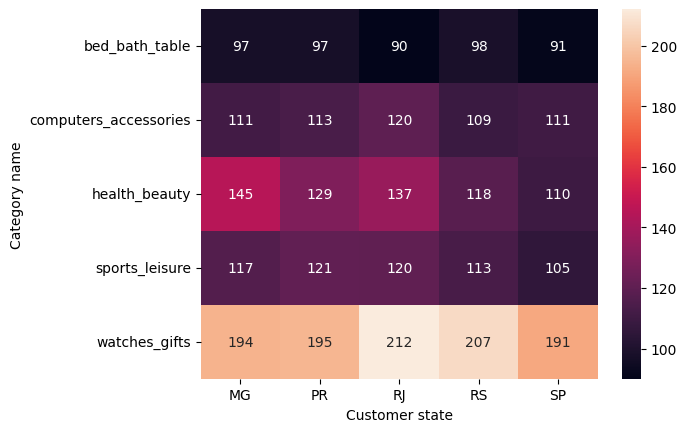

In [ ]:
# merge tables for pivot analysis

items_products_orders = pd.merge(items_products, orders, on='order_id')
items_products_orders_customers = pd.merge(items_products_orders, customers, on='customer_id')

# top-5 categories by revenue, top-5 states by order count

top_categories = items_products.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(5).index
top_states = customers.groupby('customer_state')['customer_state'].count().sort_values(ascending=False).head(5).index 

# filter by top categories and states

filtered = items_products_orders_customers[
    (items_products_orders_customers['product_category_name_english'].isin(top_categories)) &
    (items_products_orders_customers['customer_state'].isin(top_states))
]

# pivot table and heatmap

filtered_pvt = filtered.pivot_table(values='price', index='product_category_name_english', columns='customer_state', aggfunc='mean')

sns.heatmap(data=filtered_pvt, annot=True, fmt='.0f')
plt.xlabel('Customer state')
plt.ylabel('Category name')

No strong variation in average check across states within the top 5 categories. Minor exception: health_beauty ranges from ~145 (MG) to ~110 (SP). Among the top 5 categories by revenue, watches_gifts has the highest average check (~200) (roughly double that of bed_bath_table (~93)).